# Mini-Project 3: Lake Victoria Fish Stock & Export Risk Model

## Purpose
This project explores how harvesting affects fish stocks and how changing
fish prices affect revenue for a fish-export cooperative in Jinja.

## Model assumptions
The initial stock is 4,000 tonnes, the carrying capacity is 10,000 tonnes,
and the growth parameter is 0.4 per weekly step. These are illustrative
assignment values, not measured estimates for Lake Victoria.

The simulation covers 52 weeks. Each week's harvest is calculated from
the stock at the start of that week. Revenue converts harvested tonnes
into kilograms before multiplying by the price in UGX/kg.

## Approach
We first examine why Fibonacci growth is unsuitable for fish stocks.
We then model logistic growth with harvesting, simulate prices, and
compare weekly harvest fractions of 0.05, 0.10, 0.20 and 0.30.

In [15]:
import sys
from pathlib import Path
import numpy as np

# Locate the project folder from either the root or notebooks folder.
project_folder = Path.cwd()
if not (project_folder / "src").is_dir():
    project_folder = project_folder.parent

# Allow Python to find our reusable classes.
sys.path.insert(0, str(project_folder))

from src.fishstock import FishStock

# Create a fish stock object using the assignment's default parameters.
jinja_fish_stock = FishStock("Jinja Fish Cooperative")

# Check the values stored in the object.
print("Cooperative:", jinja_fish_stock.cooperative_name)
print("Initial stock:", jinja_fish_stock.initial_stock, "tonnes")
print("Carrying capacity:", jinja_fish_stock.carrying_capacity, "tonnes")
print("Weekly growth parameter:", jinja_fish_stock.growth_rate)

Cooperative: Jinja Fish Cooperative
Initial stock: 4000.0 tonnes
Carrying capacity: 10000.0 tonnes
Weekly growth parameter: 0.4


## 1. Examine the Fibonacci baseline

We begin with 15 Fibonacci numbers, starting with 0 and 1, as a
hypothetical stock sequence. Each subsequent value is the sum of
the previous two. This baseline has no calibrated biological units.

In [16]:
# Start the Fibonacci sequence with its first two values.
fibonacci_stock = [0, 1]

# Generate the remaining values until the sequence contains 15 numbers.
while len(fibonacci_stock) < 15:
    next_stock = fibonacci_stock[-1] + fibonacci_stock[-2]
    fibonacci_stock.append(next_stock)

# Display the hypothetical stock sequence.
print("Fibonacci stock baseline:", fibonacci_stock)
print("Number of values:", len(fibonacci_stock))

Fibonacci stock baseline: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]
Number of values: 15


### Limitations of Fibonacci stock growth

Fibonacci growth continues without an upper limit, whereas a lake has
limited food, space and other resources. The sequence does not model
reproduction, natural mortality or harvesting explicitly. Its growth
pattern is fixed by a numerical rule rather than estimated from fish
population data. A logistic model with harvesting is more suitable for
this exercise because it includes a carrying capacity and removes the
fish harvested each week.

## 2. Simulate stock growth and harvesting

The weekly model is:

N(t+1) = N(t) + r × N(t) × (1 − N(t)/K) − h × N(t)

Here, N(t) is stock in tonnes, r is the growth parameter, K is carrying
capacity, and h is the fraction harvested each week. Growth and harvest
are both calculated from the stock at the start of the week.

We first simulate 52 weeks using h = 0.10.

In [17]:
import importlib
import src.fishstock as fishstock

# Reload the module and create an object with the new simulation method.
importlib.reload(fishstock)
jinja_fish_stock = fishstock.FishStock("Jinja Fish Cooperative")

# Simulate one year with a weekly harvest of 10% of the starting stock.
stock_levels, weekly_harvest = jinja_fish_stock.simulate(harvest_rate=0.10)

# Check the first week's calculation and the final stock.
print("Stock observations:", len(stock_levels))
print("Weekly harvests:", len(weekly_harvest))
print(f"First week's harvest: {weekly_harvest[0]:,.2f} tonnes")
print(f"Stock after week 1: {stock_levels[1]:,.2f} tonnes")
print(f"Stock after week 52: {stock_levels[-1]:,.2f} tonnes")

Stock observations: 53
Weekly harvests: 52
First week's harvest: 400.00 tonnes
Stock after week 1: 4,560.00 tonnes
Stock after week 52: 7,500.00 tonnes


## 3. Simulate fish prices and revenue

Prices start at UGX 12,000/kg and follow a bounded random walk.
Weekly changes are drawn from a normal distribution with mean zero
and an assumed standard deviation of UGX 500/kg. Prices are clipped
to the illustrative range of UGX 9,000–16,000/kg.

Weekly revenue equals harvested tonnes × 1,000 × price per kilogram.
This is gross revenue; fishing, processing and transport costs are
not deducted. We assume all harvested fish are sold at the simulated price.

In [18]:
# Reload the module to make the PriceModel class available.
importlib.reload(fishstock)

# Generate a reproducible 52-week price path.
jinja_prices = fishstock.PriceModel()
weekly_prices = jinja_prices.simulate(weeks=52, seed=2026)

# Convert the 10% harvest scenario from tonnes to kilograms.
weekly_revenue = weekly_harvest * 1000 * weekly_prices

# Display the first five weeks to check prices and revenue.
for week in range(5):
    print(
        f"Week {week + 1}: "
        f"price = UGX {weekly_prices[week]:,.2f}/kg, "
        f"revenue = UGX {weekly_revenue[week]:,.2f}"
    )

# Sum all weekly revenues to obtain the year's gross revenue.
print(f"\nAnnual gross revenue: UGX {weekly_revenue.sum():,.2f}")

Week 1: price = UGX 12,000.00/kg, revenue = UGX 4,800,000,000.00
Week 2: price = UGX 11,603.44/kg, revenue = UGX 5,291,168,075.66
Week 3: price = UGX 11,723.72/kg, revenue = UGX 5,974,710,083.72
Week 4: price = UGX 10,775.56/kg, revenue = UGX 6,019,508,442.44
Week 5: price = UGX 11,473.45/kg, revenue = UGX 6,900,000,038.87

Annual gross revenue: UGX 462,465,030,651.71


In [19]:
import statistics

# Convert the weekly revenue array to a list for the statistics module.
revenue_values = weekly_revenue.tolist()

# Describe all 52 weeks using population variance and standard deviation.
mean_revenue = statistics.mean(revenue_values)
median_revenue = statistics.median(revenue_values)
revenue_variance = statistics.pvariance(revenue_values)
revenue_sd = statistics.pstdev(revenue_values)

# Express standard deviation relative to mean revenue.
revenue_cv = revenue_sd / mean_revenue

print(f"Mean weekly revenue: UGX {mean_revenue:,.2f}")
print(f"Median weekly revenue: UGX {median_revenue:,.2f}")
print(f"Revenue variance: {revenue_variance:,.2f} UGX²")
print(f"Revenue standard deviation: UGX {revenue_sd:,.2f}")
print(f"Coefficient of variation: {revenue_cv:.2%}")

Mean weekly revenue: UGX 8,893,558,281.76
Median weekly revenue: UGX 8,887,473,052.74
Revenue variance: 2,068,385,864,316,015,616.00 UGX²
Revenue standard deviation: UGX 1,438,188,396.67
Coefficient of variation: 16.17%


## 4. Interpret weekly revenue variation

For the 10% harvest scenario, mean weekly revenue is approximately
UGX 8.89 billion and standard deviation is UGX 1.44 billion.
The coefficient of variation (CV) is 16.17%, expressing the standard
deviation relative to the mean.

Variance is measured in UGX², so a threshold of 50,000 cannot be
interpreted as UGX 50,000 of revenue at risk. Its numerical value also
depends on the currency unit: expressing revenue in thousands of UGX
would divide the variance by one million.

CV is dimensionless and remains unchanged when the monetary unit changes.
It is therefore more useful for comparing relative revenue variability,
although any classification thresholds still require justification.

These statistics describe weekly variation within one simulated year.
They reflect both changing harvest quantities and simulated prices;
they do not measure uncertainty in total annual revenue across scenarios.

## 5. Classify relative revenue variability

For this exercise, CV below 10% is classified as low, 10% to below
20% as moderate, and 20% or above as high.

These illustrative thresholds distinguish a standard deviation below
one-tenth of mean revenue from one at least one-fifth of the mean.
They provide a consistent comparison across harvest scenarios, but
would need validation against the cooperative's costs, cash reserves
and tolerance for revenue fluctuations.

The classification describes revenue variability, not the probability
of a financial loss or the biological sustainability of harvesting.

In [20]:
# Reload the module to access the new risk assessment class.
importlib.reload(fishstock)
jinja_risk_assessor = fishstock.RiskAssessor()

# Classify weekly revenue variation for the 10% harvest scenario.
revenue_cv, risk_category = jinja_risk_assessor.classify(weekly_revenue)

print(f"Weekly revenue CV: {revenue_cv:.2%}")
print("Revenue variability risk:", risk_category)

Weekly revenue CV: 16.17%
Revenue variability risk: Moderate


## 6. Estimate annual revenue uncertainty

We simulate 1,000 different 52-week price paths while keeping the
10% harvest scenario unchanged. Each path produces one annual revenue
total, allowing us to examine uncertainty caused by prices.

The 5th percentile is reported as a lower-tail annual revenue threshold:
approximately 5% of simulated totals fall below it. This is a revenue
floor estimate, not a loss amount. It is not a guaranteed minimum.

In [21]:
# Simulate 1,000 price paths using distinct, reproducible seeds.
annual_revenues = np.zeros(1000)

for simulation in range(1000):
    simulated_prices = jinja_prices.simulate(
        weeks=52,
        seed=2026 + simulation
    )

    # Keep harvest quantities fixed to isolate price uncertainty.
    annual_revenues[simulation] = np.sum(
        weekly_harvest * 1000 * simulated_prices
    )

# Calculate the mean and lower-tail annual revenue threshold.
mean_annual_revenue = np.mean(annual_revenues)
revenue_floor_5pct = np.percentile(annual_revenues, 5)

print("Simulated price paths:", len(annual_revenues))
print(f"Mean annual revenue: UGX {mean_annual_revenue:,.2f}")
print(f"5th-percentile annual revenue: UGX {revenue_floor_5pct:,.2f}")

Simulated price paths: 1000
Mean annual revenue: UGX 452,774,066,270.41
5th-percentile annual revenue: UGX 372,896,233,431.34


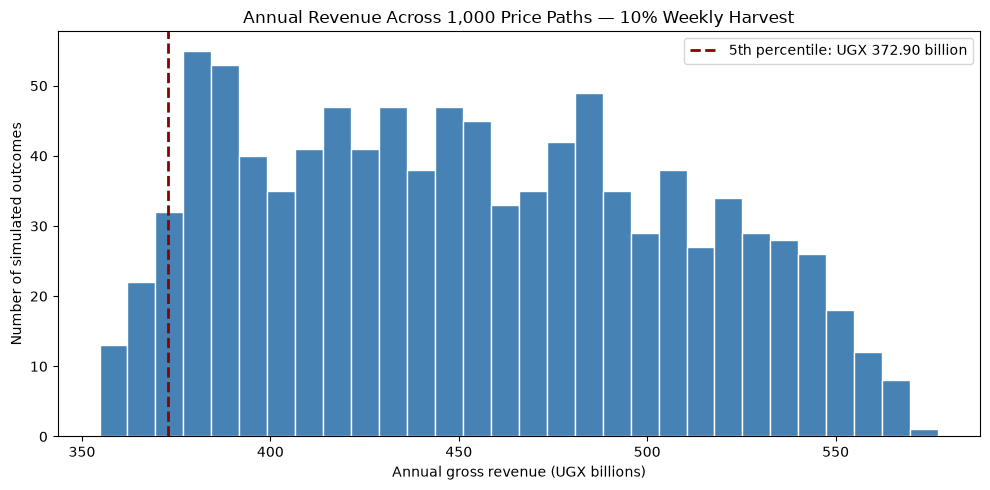

In [22]:
import matplotlib.pyplot as plt

# Display annual revenue in billions of UGX for readable labels.
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    annual_revenues / 1e9,
    bins=30,
    color="steelblue",
    edgecolor="white"
)

# Mark the lower-tail revenue threshold used for the assignment's 5% VaR.
ax.axvline(
    revenue_floor_5pct / 1e9,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"5th percentile: UGX {revenue_floor_5pct / 1e9:.2f} billion"
)

# Label the distribution and identify the harvest scenario.
ax.set_title("Annual Revenue Across 1,000 Price Paths — 10% Weekly Harvest")
ax.set_xlabel("Annual gross revenue (UGX billions)")
ax.set_ylabel("Number of simulated outcomes")
ax.legend()

fig.tight_layout()
plt.show()

## 7. Compare harvesting scenarios

We compare weekly harvest fractions of 5%, 10%, 20% and 30%.
Each scenario starts with 4,000 tonnes and uses the same simulated
price path, so differences arise from the harvesting strategy.

The table reports stock after 52 weeks, annual gross revenue and
the CV-based classification of weekly revenue variability.
These revenue figures describe one shared price path.

In [23]:
import pandas as pd

# Store stock trajectories for plotting and results for comparison.
harvest_rates = [0.05, 0.10, 0.20, 0.30]
stock_scenarios = {}
scenario_results = []

for rate in harvest_rates:
    # Simulate stock and harvest for the selected weekly fraction.
    stocks, harvests = jinja_fish_stock.simulate(harvest_rate=rate)
    stock_scenarios[rate] = stocks

    # Use the same prices for a fair comparison across harvest rates.
    revenues = harvests * 1000 * weekly_prices
    cv, category = jinja_risk_assessor.classify(revenues)

    # Collect the biological and revenue outcomes.
    scenario_results.append({
        "Weekly harvest (%)": rate * 100,
        "Final stock (tonnes)": stocks[-1],
        "Annual revenue (UGX billions)": revenues.sum() / 1e9,
        "Weekly revenue CV (%)": cv * 100,
        "Risk class": category
    })

# Display the results without rounding the underlying calculations.
scenario_table = pd.DataFrame(scenario_results)
display(scenario_table.round(2))

,Weekly harvest (%),Final stock (tonnes),Annual revenue (UGX billions),Weekly revenue CV (%),Risk class
0,5.0,8750.00,268.84,17.32,Moderate
1,10.0,7500.00,462.47,16.17,Moderate
2,20.0,4999.99,628.87,12.26,Moderate
3,30.0,2503.72,521.79,12.19,Moderate


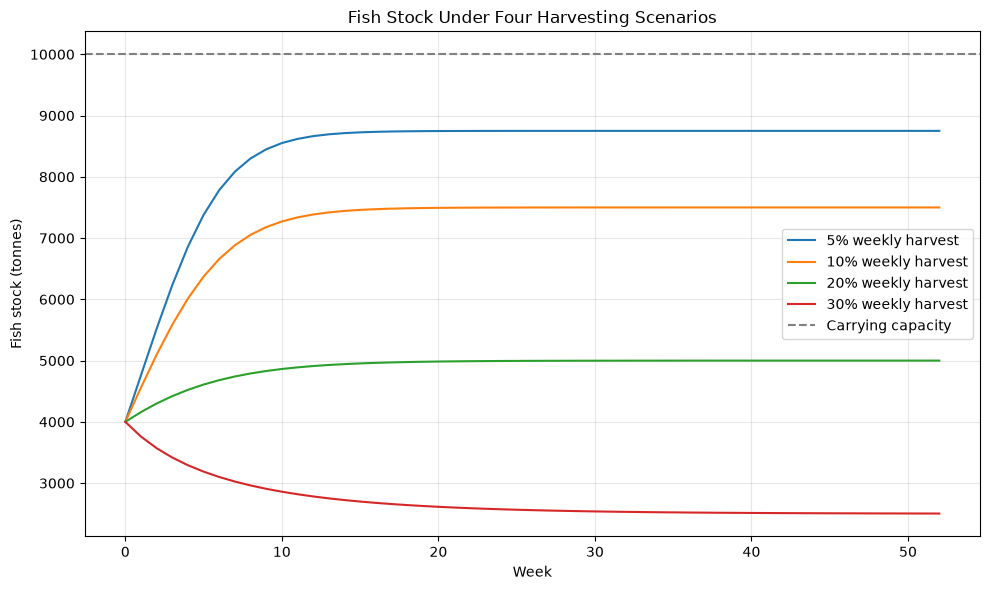

In [24]:
# Include week 0 so the chart shows the initial stock.
weeks = np.arange(53)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stock levels for each weekly harvest fraction.
for rate, stocks in stock_scenarios.items():
    ax.plot(weeks, stocks, label=f"{rate:.0%} weekly harvest")

# Show the model's environmental carrying capacity.
ax.axhline(
    jinja_fish_stock.carrying_capacity,
    color="grey",
    linestyle="--",
    label="Carrying capacity"
)

# Label the chart with time and stock units.
ax.set_title("Fish Stock Under Four Harvesting Scenarios")
ax.set_xlabel("Week")
ax.set_ylabel("Fish stock (tonnes)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Compare with maximum sustainable yield

For this logistic model, maximum sustainable yield is MSY = rK/4.
With r = 0.4 and K = 10,000 tonnes, this equals 1,000 tonnes per week
and occurs at a stock of K/2 = 5,000 tonnes.

Under proportional harvesting, the positive equilibrium stock is
K(1 − h/r), provided h < r. Multiplying this stock by h gives the
weekly harvest that can be maintained at equilibrium.

These are theoretical results for the assignment's model, not a
recommended fishing quota for Lake Victoria.

In [25]:
# Calculate the model's maximum sustainable weekly harvest.
r = jinja_fish_stock.growth_rate
capacity = jinja_fish_stock.carrying_capacity
msy = r * capacity / 4

print(f"Maximum sustainable yield: {msy:,.2f} tonnes per week")
print(f"Stock at MSY: {capacity / 2:,.2f} tonnes")

# Compare long-run equilibrium yields for the four harvest fractions.
for rate in harvest_rates:
    equilibrium_stock = capacity * (1 - rate / r)
    equilibrium_yield = rate * equilibrium_stock

    print(
        f"\nHarvest rate {rate:.0%}: "
        f"equilibrium stock = {equilibrium_stock:,.2f} tonnes, "
        f"weekly yield = {equilibrium_yield:,.2f} tonnes "
        f"({equilibrium_yield / msy:.1%} of MSY)"
    )

Maximum sustainable yield: 1,000.00 tonnes per week
Stock at MSY: 5,000.00 tonnes

Harvest rate 5%: equilibrium stock = 8,750.00 tonnes, weekly yield = 437.50 tonnes (43.8% of MSY)

Harvest rate 10%: equilibrium stock = 7,500.00 tonnes, weekly yield = 750.00 tonnes (75.0% of MSY)

Harvest rate 20%: equilibrium stock = 5,000.00 tonnes, weekly yield = 1,000.00 tonnes (100.0% of MSY)

Harvest rate 30%: equilibrium stock = 2,500.00 tonnes, weekly yield = 750.00 tonnes (75.0% of MSY)


### Interpretation of harvesting sustainability

The 20% weekly harvest fraction reaches the theoretical maximum
sustainable yield of 1,000 tonnes per week at an equilibrium stock
of 5,000 tonnes. It also generated the highest first-year revenue
among the four scenarios under the shared simulated price path.

Increasing the harvest fraction to 30% reduces equilibrium stock to
2,500 tonnes and equilibrium yield to 750 tonnes per week. The 10%
scenario supports the same equilibrium yield while maintaining
7,500 tonnes of stock.

All four harvest fractions are below the growth parameter of 0.4
and approach positive equilibria in these simulations. However,
the 30% scenario maintains a smaller biological reserve.

A weekly harvest can temporarily exceed MSY by drawing down stock.
For example, the 30% scenario initially harvests 1,200 tonnes while
natural growth is only 960 tonnes, causing stock to fall.

These outcomes assume constant biological parameters and exclude
environmental shocks. Revenue variability classifications alone
cannot establish whether harvesting is biologically sustainable.

## 9. Extension: an eight-week annual closed season

We compare continuous fishing with a closure during weeks 1–8 of
each year, over five years (260 weeks). The open-season harvest
fraction remains 20%, with no extra harvesting to compensate for closure.

Both scenarios start with 4,000 tonnes and use the same simulated
price path. This isolates the effect of the closure under our model.
The closure dates are an illustrative assumption, not a fishing regulation.

In [26]:
# Reload the updated class and create a fresh stock object.
importlib.reload(fishstock)
jinja_fish_stock = fishstock.FishStock("Jinja Fish Cooperative")

# Generate one shared price path for all 260 weeks.
five_year_prices = jinja_prices.simulate(weeks=260, seed=2026)

# Compare continuous fishing with an annual eight-week closure.
open_stock, open_harvest = jinja_fish_stock.simulate(
    harvest_rate=0.20, weeks=260
)
closed_stock, closed_harvest = jinja_fish_stock.simulate(
    harvest_rate=0.20, weeks=260, closed_season=True
)

# Calculate gross revenue using the same prices in both scenarios.
open_revenue = open_harvest * 1000 * five_year_prices
closed_revenue = closed_harvest * 1000 * five_year_prices

# Report the closure's effect on total revenue and final stock.
revenue_change = closed_revenue.sum() - open_revenue.sum()
percentage_change = revenue_change / open_revenue.sum() * 100

print(f"Continuous fishing revenue: UGX {open_revenue.sum():,.2f}")
print(f"Closed-season revenue: UGX {closed_revenue.sum():,.2f}")
print(f"Revenue change: UGX {revenue_change:+,.2f} ({percentage_change:+.2f}%)")
print(f"Final stock, continuous fishing: {open_stock[-1]:,.2f} tonnes")
print(f"Final stock, closed season: {closed_stock[-1]:,.2f} tonnes")

Continuous fishing revenue: UGX 3,427,989,623,049.18
Closed-season revenue: UGX 3,120,181,425,106.13
Revenue change: UGX -307,808,197,943.05 (-8.98%)
Final stock, continuous fishing: 5,000.00 tonnes
Final stock, closed season: 5,000.11 tonnes


In [27]:
# Compare start-of-week stock across the full five-year period.
print(f"Average stock, continuous fishing: {open_stock[:-1].mean():,.2f} tonnes")
print(f"Average stock, closed season: {closed_stock[:-1].mean():,.2f} tonnes")

# Group weekly revenues into five years of 52 weeks each.
annual_open = open_revenue.reshape(5, 52).sum(axis=1)
annual_closed = closed_revenue.reshape(5, 52).sum(axis=1)

# Display yearly revenue and the percentage effect of the closure.
closure_comparison = pd.DataFrame({
    "Year": np.arange(1, 6),
    "Continuous fishing (UGX billions)": annual_open / 1e9,
    "Closed season (UGX billions)": annual_closed / 1e9,
    "Revenue change (%)": (annual_closed / annual_open - 1) * 100
})

display(closure_comparison.round(2))

Average stock, continuous fishing: 4,978.30 tonnes
Average stock, closed season: 5,707.99 tonnes


,Year,Continuous fishing (UGX billions),Closed season (UGX billions),Revenue change (%)
0,1,628.87,585.49,-6.90
1,2,697.05,616.76,-11.52
2,3,635.92,579.79,-8.83
3,4,747.93,696.35,-6.90
4,5,718.22,641.79,-10.64


### Closed-season findings

At a 20% open-season harvest fraction, closing fishing for eight weeks
annually reduced five-year gross revenue from approximately UGX 3.428
trillion to UGX 3.120 trillion, a decline of 8.98% on the shared price path.

Average start-of-week stock increased from 4,978.30 to 5,707.99 tonnes,
approximately 14.7%. The closure therefore maintained a larger average
fish stock, although it did not increase revenue over this simulation.

Final stocks were similar because each year ended after 44 consecutive
fishing weeks. During those weeks, both scenarios approached the
5,000-tonne equilibrium associated with 20% harvesting.

These results describe five simulated years under fixed biological
parameters and one price path. They do not establish that closures
always reduce revenue or quantify benefits such as protecting spawning,
which this model does not explicitly represent.

## 10. Findings & Limitations

The logistic model gives a more defensible representation of fish stock
than unbounded Fibonacci growth because it includes carrying capacity
and harvesting. All four tested harvest fractions approached positive
equilibria, although their stock levels and yields differed.

The 20% weekly harvest scenario generated the highest first-year revenue,
approximately UGX 628.87 billion on the shared price path. Its equilibrium
stock of 5,000 tonnes supports the theoretical maximum sustainable yield
of 1,000 tonnes per week. Increasing harvesting to 30% reduced equilibrium
stock to 2,500 tonnes and weekly yield to 750 tonnes.

For the 10% scenario, weekly revenue CV was 16.17%, classified as moderate
under the illustrative thresholds. Across 1,000 price paths, mean annual
revenue was approximately UGX 452.77 billion, with a 5th-percentile revenue
threshold of UGX 372.90 billion. This threshold describes lower-tail
revenue, not a guaranteed minimum or a loss amount.

At 20% harvesting, an eight-week annual closure increased average stock
by approximately 14.7% but reduced five-year revenue by 8.98% on one
shared price path.

The biological parameters, price fluctuations and risk thresholds are
illustrative. The model excludes environmental shocks, species differences,
fishing costs and price responses to supply. Monte Carlo results capture
only the specified price uncertainty. Actual management decisions would
require measured biological and market data, together with stakeholder
assessment of acceptable ecological and financial risks.